In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_roe = pd.read_csv("../data/processed/roe_2021_2025.csv")

In [2]:
df_roe

,DENOM_CIA,SETOR_ATIV,ANO_ARQUIVO,VL_CONTA_LUCRO,VL_CONTA_REAIS,VL_CONTA_BI,VL_CONTA_PL,ROE,ROE_ENGANOSO
0,COSAN S.A.,"Agricultura (Açúcar, Álcool e Cana)",2021,14519180.0,1.451918e+10,14.519180,28870022.0,0.502915,False
1,JBS S.A.,Alimentos,2021,25184602.0,2.518460e+10,25.184602,47796720.0,0.526911,False
2,BCO BRADESCO S.A.,Bancos,2021,39414765.0,3.941476e+10,39.414765,150228707.0,0.262365,False
3,BCO BRASIL S.A.,Bancos,2021,33015754.0,3.301575e+10,33.015754,146110233.0,0.225965,False
4,BCO SANTANDER (BRASIL) S.A.,Bancos,2021,29010076.0,2.901008e+10,29.010076,105974495.0,0.273746,False
...,...,...,...,...,...,...,...,...,...
379,LOCALIZA RENT A CAR S.A.,Serviços Transporte e Logística,2025,7367560.0,7.367560e+09,7.367560,25539012.0,0.288483,False
380,TELEFÔNICA BRASIL S.A,Telecomunicações,2025,11734875.0,1.173488e+10,11.734875,69002726.0,0.170064,False
381,TIM BRASIL SERVIÇOS E PARTICIPAÇÕES S.A.,Telecomunicações,2025,5800850.0,5.800850e+09,5.800850,19545484.0,0.296787,False
382,V. TAL - REDE NEUTRA DE TELECOMUNICAÇÕES S.A.,Telecomunicações,2025,-12991140.0,-1.299114e+10,-12.991140,16459637.0,-0.789273,False


In [4]:
roe_por_setor_ano = df_roe.groupby(["SETOR_ATIV", "ANO_ARQUIVO"])["ROE"].mean().reset_index()

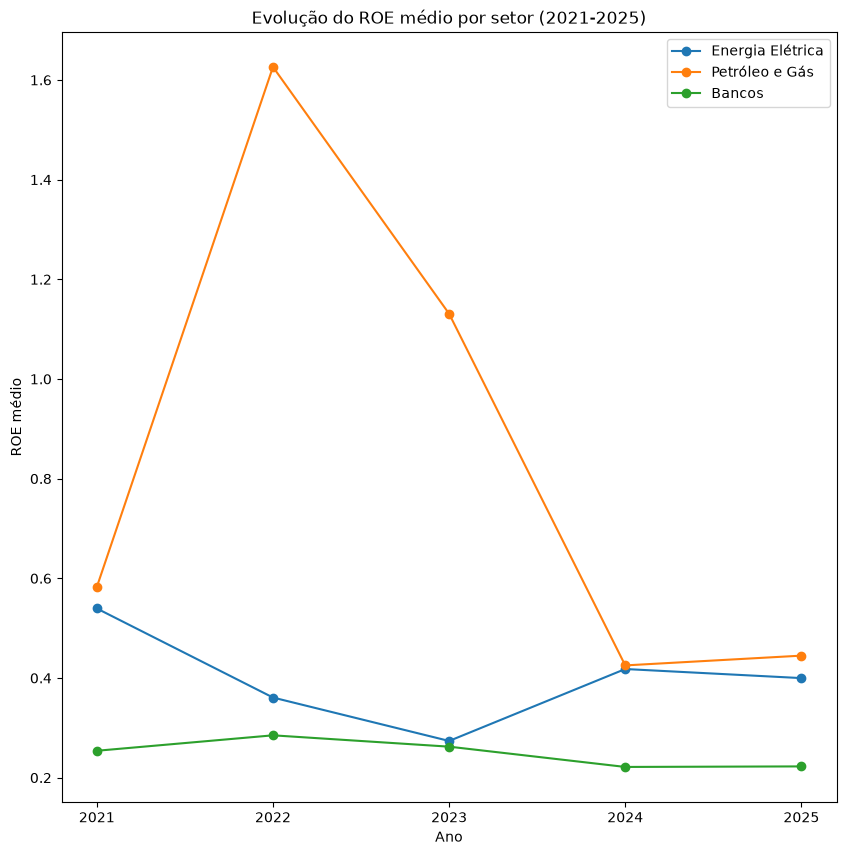

In [8]:
setores_escolhidos = ["Energia Elétrica", "Petróleo e Gás","Bancos"]  

roe_medio = df_roe.groupby(["SETOR_ATIV", "ANO_ARQUIVO"])["ROE"].mean().reset_index()

plt.figure(figsize=(10, 10))

for setor in setores_escolhidos:
    dados_setor = roe_medio[roe_medio["SETOR_ATIV"] == setor]
    plt.plot(dados_setor["ANO_ARQUIVO"], dados_setor["ROE"], marker="o", label=setor)

plt.title("Evolução do ROE médio por setor (2021-2025)")
plt.xlabel("Ano")
plt.xticks([2021, 2022, 2023, 2024, 2025])
plt.ylabel("ROE médio")
plt.legend()
plt.show()

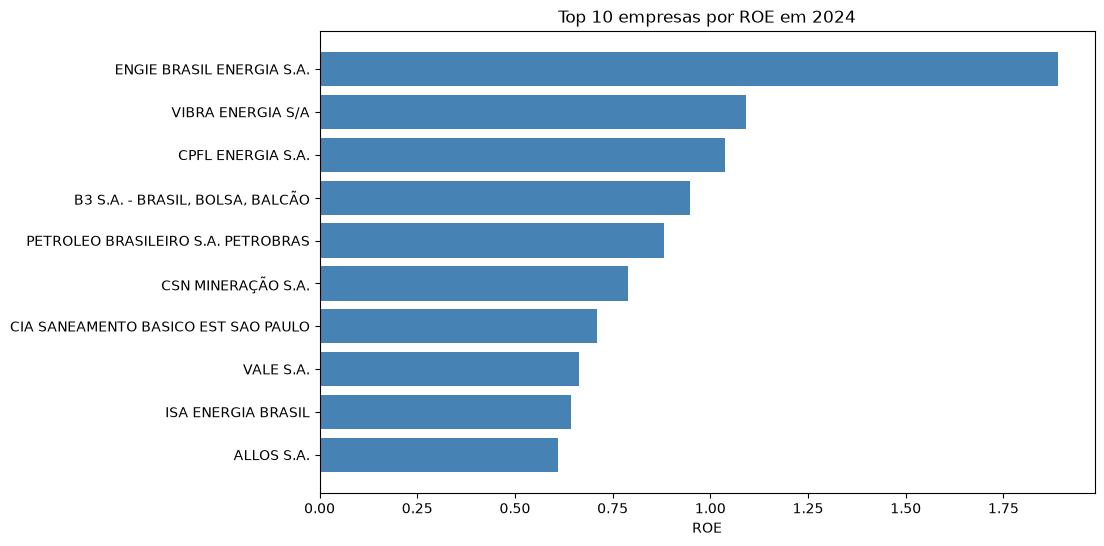

In [9]:
ano_escolhido = 2024

top10 = df_roe[df_roe["ANO_ARQUIVO"] == ano_escolhido].sort_values("ROE", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["DENOM_CIA"], top10["ROE"], color="steelblue")
plt.title(f"Top 10 empresas por ROE em {ano_escolhido}")
plt.xlabel("ROE")
plt.gca().invert_yaxis()  # deixa o maior valor no topo, não embaixo
plt.show()

In [11]:
df_lucro= pd.read_csv("../data/processed/lucro_liquido_2021_2025.csv")
df_lucro

,DENOM_CIA,SETOR_ATIV,ANO_ARQUIVO,VL_CONTA,VL_CONTA_REAIS,VL_CONTA_BI
0,COSAN S.A.,"Agricultura (Açúcar, Álcool e Cana)",2021,14519180.0,1.451918e+10,14.519180
1,SLC AGRICOLA S.A.,"Agricultura (Açúcar, Álcool e Cana)",2021,1641707.0,1.641707e+09,1.641707
2,SAO MARTINHO S.A.,"Agricultura (Açúcar, Álcool e Cana)",2021,1566134.0,1.566134e+09,1.566134
3,RAIZEN ENERGIA S.A.,"Agricultura (Açúcar, Álcool e Cana)",2021,867927.0,8.679270e+08,0.867927
4,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,"Agricultura (Açúcar, Álcool e Cana)",2021,437200.0,4.372000e+08,0.437200
...,...,...,...,...,...,...
2259,CIA INDUSTRIAL SCHLOSSER S.A.,Têxtil e Vestuário,2025,-467.0,-4.670000e+05,-0.000467
2260,FIACAO E TECELAGEM SAO JOSE SA EM RECUPERACAO ...,Têxtil e Vestuário,2025,-17600.0,-1.760000e+07,-0.017600
2261,MUNDIAL S.A. - PRODUTOS DE CONSUMO,Têxtil e Vestuário,2025,-18152.0,-1.815200e+07,-0.018152
2262,TEXTIL RENAUXVIEW S.A.,Têxtil e Vestuário,2025,-96538.0,-9.653800e+07,-0.096538


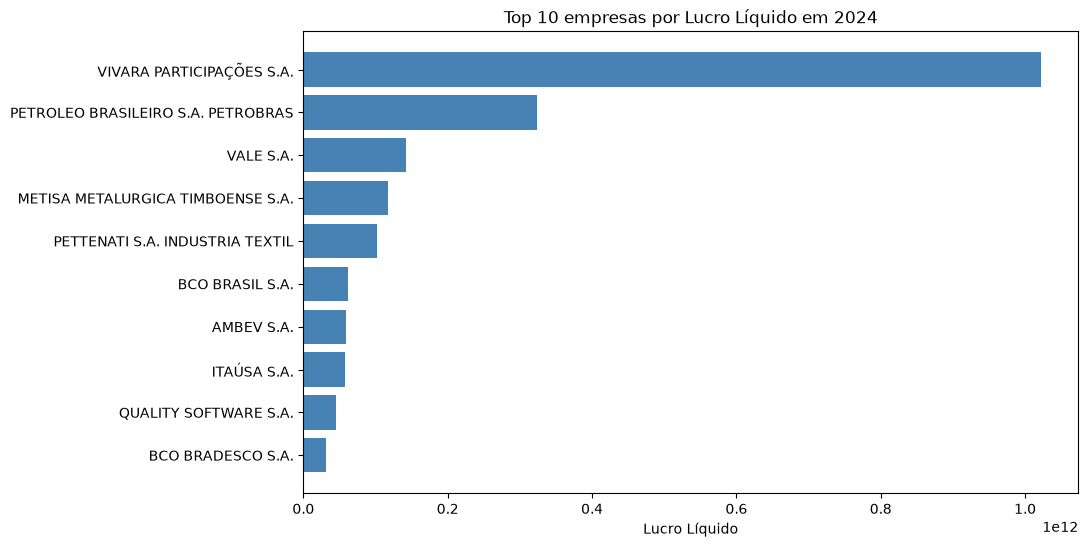

In [12]:
ano_escolhido = 2024



top10 = df_lucro[df_lucro["ANO_ARQUIVO"] == ano_escolhido].sort_values("VL_CONTA_REAIS", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["DENOM_CIA"], top10["VL_CONTA_REAIS"], color="steelblue")
plt.title(f"Top 10 empresas por Lucro Líquido em {ano_escolhido}")
plt.xlabel("Lucro Líquido")
plt.gca().invert_yaxis()  # deixa o maior valor no topo, não embaixo
plt.show()

In [13]:
df_roe[df_roe["DENOM_CIA"].str.contains("WEG", case=False, na=False)]

,DENOM_CIA,SETOR_ATIV,ANO_ARQUIVO,VL_CONTA_LUCRO,VL_CONTA_REAIS,VL_CONTA_BI,VL_CONTA_PL,ROE,ROE_ENGANOSO
24,WEG S.A.,"Emp. Adm. Part. - Máqs., Equip., Veíc. e Peças",2021,6053437.0,6.053437e+09,6.053437,14010672.0,0.432059,False
88,WEG S.A.,"Emp. Adm. Part. - Máqs., Equip., Veíc. e Peças",2022,7930352.0,7.930352e+09,7.930352,15248355.0,0.520079,False
161,WEG S.A.,"Emp. Adm. Part. - Máqs., Equip., Veíc. e Peças",2023,10140487.0,1.014049e+10,10.140487,17854776.0,0.567943,False
246,WEG S.A.,"Emp. Adm. Part. - Máqs., Equip., Veíc. e Peças",2024,12186378.0,1.218638e+10,12.186378,23125217.0,0.526974,False
333,WEG S.A.,"Emp. Adm. Part. - Máqs., Equip., Veíc. e Peças",2025,13094721.0,1.309472e+10,13.094721,18553364.0,0.705787,False


In [ ]:
idx_melhores = df_roe.groupby("DENOM_CIA")["ROE"].idxmax()
melhores_por_empresa = df_roe.loc[idx_melhores]
melhores_por_empresa = melhores_por_empresa[~melhores_por_empresa["ROE_ENGANOSO"]]

top10_sem_repeticao = melhores_por_empresa.sort_values("ROE", ascending=False).head(10)
top10_sem_repeticao

KeyError: False